In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# First I read in the data
indeed_w1 = pd.read_csv("./new_data/Indeed_w1.csv", sep=",", skiprows=1)
indeed_w2 = pd.read_csv("./new_data/Indeed_w2.csv", sep=",", skiprows=1)
indeed_w3 = pd.read_csv("./new_data/Indeed_w3.csv", sep=",", skiprows=1)

stepstone_w1 = pd.read_csv("./new_data/Stepstone_w1.csv", sep=",", skiprows=1)
stepstone_w2 = pd.read_csv("./new_data/Stepstone_w2.csv", sep=",", skiprows=1)
stepstone_w3 = pd.read_csv("./new_data/Stepstone_w3.csv", sep=",", skiprows=1)

Bewerbung_w1 = pd.read_csv("./new_data/Bewerbung_w1.csv", sep=",", skiprows=1)
Bewerbung_w2 = pd.read_csv("./new_data/Bewerbung_w2.csv", sep=",", skiprows=1)
Bewerbung_w3 = pd.read_csv("./new_data/Bewerbung_w3.csv", sep=",", skiprows=1)

arbeitsamt_w1 = pd.read_csv("./new_data/Arbeitsamt_w1.csv", sep=",", skiprows=1)
arbeitsamt_w2 = pd.read_csv("./new_data/Arbeitsamt_w2.csv", sep=",", skiprows=1)
arbeitsamt_w3 = pd.read_csv("./new_data/Arbeitsamt_w3.csv", sep=",", skiprows=1)

jobbörse_w1 = pd.read_csv("./new_data/Jobbörse_w1.csv", sep=",", skiprows=1)
jobbörse_w2 = pd.read_csv("./new_data/Jobbörse_w2.csv", sep=",", skiprows=1)
jobbörse_w3 = pd.read_csv("./new_data/Jobbörse_w3.csv", sep=",", skiprows=1)

# Define the columns
indeed_w1.columns = ["Date", "indeed"]
indeed_w2.columns = ["Date", "indeed"]
indeed_w3.columns = ["Date", "indeed"]

stepstone_w1.columns = ["Date", "stepstone"]
stepstone_w2.columns = ["Date", "stepstone"]
stepstone_w3.columns = ["Date", "stepstone"]

Bewerbung_w1.columns = ["Date","bewerbung"]
Bewerbung_w2.columns = ["Date","bewerbung"]
Bewerbung_w3.columns = ["Date","bewerbung"]

arbeitsamt_w1.columns = ["Date", "arbeitsamt"]
arbeitsamt_w2.columns = ["Date", "arbeitsamt"]
arbeitsamt_w3.columns = ["Date", "arbeitsamt"]

jobbörse_w1.columns = ["Date", "jobbörse"]
jobbörse_w2.columns = ["Date", "jobbörse"]
jobbörse_w3.columns = ["Date", "jobbörse"]






In [2]:
# make them date
for df in [indeed_w1,indeed_w2,indeed_w3, stepstone_w1, stepstone_w2, stepstone_w3, Bewerbung_w1,Bewerbung_w2,Bewerbung_w3, arbeitsamt_w1,arbeitsamt_w2,arbeitsamt_w3, jobbörse_w1, jobbörse_w2, jobbörse_w3]:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    # convert value column to numercic (some lines may have non-numeric stuff)
    df[df.columns[1]] = pd.to_numeric(df[df.columns[1]], errors="coerce")

In [3]:
import pandas as pd
import numpy as np

# --- Endpoints: weekly vs monthly
START = pd.Timestamp("2011-05-01")      # Sunday
END_WEEK = pd.Timestamp("2023-01-29")   # Sunday
END_MONTH = pd.Timestamp("2023-01-31")  # Month-end label for monthly data

def _prep(df, value_col):
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
    df = df.dropna(subset=["Date", value_col]).set_index("Date").sort_index()
    return df

def _median_ratio(a, b):
    idx = a.index.intersection(b.index)
    x, y = a.loc[idx], b.loc[idx]
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() == 0:
        return 1.0
    return np.median((x[mask] / y[mask]).values)

def stitch_three(w1, w2, w3, value_col, final_name=None):
    W1 = _prep(w1, value_col)
    W2 = _prep(w2, value_col)
    W3 = _prep(w3, value_col)

    s21 = _median_ratio(W1[value_col], W2[value_col])
    W2r = W2 * s21

    s32 = _median_ratio(W2r[value_col], W3[value_col])
    W3r = W3 * s32

    out = pd.concat([
        W1,
        W2r.loc[~W2r.index.isin(W1.index)],
        W3r.loc[~W3r.index.isin(W1.index.union(W2r.index))]
    ]).sort_index()

    # Trim to weekly analysis window (Sundays)
    out = out.loc[(out.index >= START) & (out.index <= END_WEEK)].copy()

    if final_name is None:
        final_name = value_col
    out.columns = [final_name]
    out = out.reset_index().rename(columns={"index": "Date"})
    return out

# --- Build stitched weekly series
indeed     = stitch_three(indeed_w1,     indeed_w2,     indeed_w3,     "indeed",     "indeed")
stepstone  = stitch_three(stepstone_w1,  stepstone_w2,  stepstone_w3,  "stepstone",  "stepstone")
Bewerbung  = stitch_three(Bewerbung_w1,  Bewerbung_w2,  Bewerbung_w3,  "bewerbung",  "bewerbung")
arbeitsamt = stitch_three(arbeitsamt_w1, arbeitsamt_w2, arbeitsamt_w3, "arbeitsamt", "arbeitsamt")
jobbörse   = stitch_three(jobbörse_w1,   jobbörse_w2,   jobbörse_w3,   "jobbörse",   "jobbörse")

# --- Sanity (weekly Sunday grid)
for name, d in [("indeed", indeed), ("stepstone", stepstone), ("jobbörse", jobbörse), ("arbeitsamt", arbeitsamt), ("Bewerbung", Bewerbung)]:
    assert d["Date"].min() == START and d["Date"].max() == END_WEEK, f"{name} weekly range mismatch"
    assert (d["Date"].diff().dropna().dt.days == 7).all(), f"{name} not weekly by 7-day steps"

# --- Merge (weekly aligned)
df_week = (stepstone.merge(indeed,     on="Date", how="inner")
                   .merge(jobbörse,   on="Date", how="inner")
                   .merge(arbeitsamt, on="Date", how="inner")
                   .merge(Bewerbung,  on="Date", how="inner"))

# Optional: save weekly
# df_week.to_csv("./new_data/google_weekly_stitched_merged.csv", index=False)

# --- If you want MONTHLY (to align with unemployment at month-end labels)
df_month = (df_week.set_index("Date")
                    .resample("M").mean()
                    .reset_index())
# Ensure last label is 2023-01-31
assert df_month["Date"].max() == END_MONTH, "Monthly last date not 2023-01-31"

# Optional: save monthly
# df_month.to_csv("./new_data/google_monthly_stitched_merged.csv", index=False)

/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_75809/754286074.py:73: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M").mean()


In [4]:
# ==========================================================
#  BIWEEKLY AGGREGATION  (Zimmer-style W12 / W34prev design)
# ==========================================================
import pandas as pd

# df_week: weekly merged Google Trends (columns like ['stepstone','indeed','jobbörse','arbeitsamt','bewerbung'])
# Date column: weekly Sundays
wk = df_week.copy()
wk["Date"] = pd.to_datetime(wk["Date"])
wk = wk.set_index("Date").sort_index()

# --- Helper calendar columns
wk["year"]  = wk.index.year
wk["month"] = wk.index.month
wk["day"]   = wk.index.day

# --- W12(M): weeks from days 1–15 within month M (early-month activity)
w12 = (
    wk[wk["day"] <= 15]
    .groupby(pd.Grouper(freq="M"))[
        ["stepstone","indeed","jobbörse","arbeitsamt","bewerbung"]
    ].mean()
)
w12.columns = [c + "_W12" for c in w12.columns]

# --- W34(M−1): weeks from days >15 of month M−1 (late-month activity)
# Shift forward by one month to align them with month M
w34_prev = (
    wk[wk["day"] > 15]
    .groupby(pd.Grouper(freq="M"))[
        ["stepstone","indeed","jobbörse","arbeitsamt","bewerbung"]
    ].mean()
)
w34_prev = w34_prev.shift(1, freq="M")
w34_prev.columns = [c + "_W34prev" for c in w34_prev.columns]

# --- Combine W12 and W34prev into a biweekly feature panel aligned to month M
biweekly = pd.concat([w12, w34_prev], axis=1).sort_index()

# --- Trim to your analytical window (month-end timestamps)
biweekly = biweekly.loc["2011-05-31":"2023-01-31"]

print("✅ Biweekly feature panel created:")
print(biweekly.head())
print(biweekly.tail())
print("Shape:", biweekly.shape)

✅ Biweekly feature panel created:
            stepstone_W12  indeed_W12  jobbörse_W12  arbeitsamt_W12  \
Date                                                                  
2011-05-31      50.333333        14.0     78.333333       85.666667   
2011-06-30      49.500000        14.5     79.500000       76.500000   
2011-07-31      52.000000        16.5     88.500000       85.500000   
2011-08-31      54.000000        15.5     93.500000       79.500000   
2011-09-30      52.500000        16.5     95.000000       79.000000   

            bewerbung_W12  stepstone_W34prev  indeed_W34prev  \
Date                                                           
2011-05-31           68.0                NaN             NaN   
2011-06-30           69.5          47.000000       14.000000   
2011-07-31           86.5          51.500000       15.000000   
2011-08-31           73.0          52.333333       15.666667   
2011-09-30           73.5          54.000000       15.500000   

            jobbörs

/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_75809/2344181062.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(freq="M"))[
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_75809/2344181062.py:30: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(freq="M"))[
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_75809/2344181062.py:34: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  w34_prev = w34_prev.shift(1, freq="M")


In [5]:
# unemployment 
data = pd.read_csv("unemployment_rate_germany_DE_only.csv", sep=',')
data_copy = data.copy()
data = data[(data["Date"]>= "2011-05-01") & (data["Date"] <= "2023-01-01")]
unemp = data 

unemp.columns = ["Date", "Unemp"]
unemp["Date"] = pd.to_datetime(unemp["Date"])
unemp = unemp.set_index("Date")
# align to month-end index
unemp.index = unemp.index.to_period("M").to_timestamp("M")
panel = biweekly.join(unemp, how="inner")
panel = panel.dropna()


In [6]:
panel

,stepstone_W12,indeed_W12,jobbörse_W12,arbeitsamt_W12,bewerbung_W12,stepstone_W34prev,indeed_W34prev,jobbörse_W34prev,arbeitsamt_W34prev,bewerbung_W34prev,Unemp
Date,,,,,,,,,,,
2011-06-30,49.500000,14.500000,79.500000,76.500000,69.500000,47.000000,14.000000,74.500000,78.000000,66.500000,6.9
2011-07-31,52.000000,16.500000,88.500000,85.500000,86.500000,51.500000,15.000000,83.000000,82.500000,77.000000,7.0
2011-08-31,54.000000,15.500000,93.500000,79.500000,73.000000,52.333333,15.666667,87.000000,82.666667,70.333333,7.0
2011-09-30,52.500000,16.500000,95.000000,79.000000,73.500000,54.000000,15.500000,91.500000,81.500000,71.500000,6.6
2011-10-31,51.500000,18.500000,86.500000,78.500000,71.000000,55.500000,17.000000,91.000000,79.000000,76.000000,6.5
...,...,...,...,...,...,...,...,...,...,...,...
2022-09-30,53.641265,128.215336,15.113878,25.519451,39.527799,55.490964,130.073529,16.313392,28.146453,38.187873,5.4
2022-10-31,54.011205,126.357143,14.394169,24.018307,37.182929,55.490964,127.286239,14.873975,27.020595,39.862780,5.3
2022-11-30,55.121024,131.931723,14.634072,24.018307,38.857836,55.490964,127.595938,13.914364,24.518688,36.624627,5.3


# Nowcasting using a ARX 
This is to include the newest information

In [7]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

def arx_diff_nowcast(panel, gt_col,
                     start_eval="2019-01-01",
                     p_ar=2,        # AR lags of ΔUnemp
                     q_gt=0,        # number of lags of ΔGT (0 = only contemporaneous)
                     min_train=60,  # minimal obs in estimation window
                     plot=True,
                     show_summary=True):
    """
    Rolling pseudo-real-time nowcast with ARX in first differences:
    ΔUnemp_t ~ AR(p) in ΔUnemp + ΔGT_t (and lags) + monthly dummies.

    - Training sample for each forecast date t: all data with Date < t
    - Forecast horizon: 1 month ahead (nowcast current month t)
    - start_eval: first month (by date) for which you start evaluating nowcasts.
    """

    # 1) Keep only GT series and unemployment, convert to numeric
    df = panel[[gt_col, "Unemp"]].copy()
    df[gt_col] = pd.to_numeric(df[gt_col], errors="coerce")
    df["Unemp"] = pd.to_numeric(df["Unemp"], errors="coerce")

    # 2) First differences
    df["dUnemp"] = df["Unemp"].diff()
    df["dGT"] = df[gt_col].diff()

    # 3) Precompute AR lags of ΔUnemp
    for i in range(1, p_ar + 1):
        df[f"dUnemp_lag{i}"] = df["dUnemp"].shift(i)

    # 4) Precompute ΔGT current and lags
    df["dGT_0"] = df["dGT"]  # contemporaneous ΔGT_t
    for j in range(1, q_gt + 1):
        df[f"dGT_lag{j}"] = df["dGT"].shift(j)

    # 5) Monthly dummies (Feb–Dec; Jan baseline)
    month_dummies = pd.get_dummies(df.index.month, prefix="m", drop_first=True)
    month_dummies.index = df.index

    # Regressor columns (AR lags + GT terms)
    reg_cols = [f"dUnemp_lag{i}" for i in range(1, p_ar + 1)] + ["dGT_0"] \
               + [f"dGT_lag{j}" for j in range(1, q_gt + 1)]

    forecasts = []
    actuals = []
    dates = []
    last_arx_res = None

    # Evaluation dates
    eval_dates = df.loc[start_eval:].index

    for t in eval_dates:
        # 1) Estimation sample: everything BEFORE t
        df_est = df.loc[df.index < t].copy()
        # drop first row (diff NaN) and potential early NaNs from lags
        df_est = df_est.iloc[1:]

        # y = ΔUnemp
        y_est = df_est["dUnemp"]

        # X = AR lags of ΔUnemp + ΔGT terms + month dummies
        X_est = df_est[reg_cols]
        dummies_est = month_dummies.loc[df_est.index]

        X_est = pd.concat([X_est, dummies_est], axis=1)

        # Combine and drop rows with any NaN (from early lags)
        reg_data = pd.concat([y_est, X_est], axis=1).dropna()

        if reg_data.empty:
            continue

        # Split again
        y_reg = reg_data["dUnemp"].astype(float)
        X_reg = reg_data.drop(columns=["dUnemp"]).astype(float)

        if len(y_reg) < max(min_train, p_ar + q_gt + 2):
            # Not enough data yet, skip this t
            continue

        # Add constant
        X_reg = sm.add_constant(X_reg)

        # 2) Fit ARX (OLS on first differences)
        arx_res = sm.OLS(y_reg, X_reg).fit()
        last_arx_res = arx_res

        # 3) Build regressor row for forecast month t
        #    We already have all lagged columns in df for date t
        x_t = df.loc[[t], reg_cols]
        dummies_t = month_dummies.loc[[t]]

        x_t = pd.concat([x_t, dummies_t], axis=1).astype(float)
        x_t = sm.add_constant(x_t, has_constant="add")

        # 4) Predict ΔUnemp_t
        dU_pred = float(arx_res.predict(x_t))

        # 5) Back to level forecast: U_t = U_{t-1} + ΔU_t
        U_last = df.loc[df.index < t, "Unemp"].iloc[-1]
        U_pred = U_last + dU_pred

        forecasts.append(U_pred)
        actuals.append(df.loc[t, "Unemp"])
        dates.append(t)

    forecasts = pd.Series(forecasts, index=dates, name="Unemp_nowcast_ARX")
    actuals = pd.Series(actuals, index=dates, name="Unemp_actual")

    errors = forecasts - actuals
    rmse = np.sqrt(np.mean(errors**2))
    mae = np.mean(np.abs(errors))

    print(f"\nARX(Δ) nowcast for {gt_col}: RMSE={rmse:.4f}, MAE={mae:.4f}")

    if show_summary and last_arx_res is not None:
        print("\n=== Last ARX(Δ) estimation summary (with monthly dummies) ===")
        print(last_arx_res.summary())

    if plot:
        plt.figure(figsize=(10, 4))
        plt.plot(actuals, label="Unemp actual")
        plt.plot(forecasts, label="Unemp nowcast (ARX)", linestyle="--")
        plt.title(f"ARX(Δ) nowcast using {gt_col} with monthly dummies\n(start_eval={start_eval})")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return forecasts, actuals, rmse, mae, last_arx_res


/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_75809/2314558685.py:101: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  dU_pred = float(arx_res.predict(x_t))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_75809/2314558685.py:101: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  dU_pred = float(arx_res.predict(x_t))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_75809/2314558685.py:101: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  dU_pred = float(arx_res.predict(x_t))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_75809/2314558685.py:101: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use


ARX(Δ) nowcast for stepstone_W12: RMSE=0.1846, MAE=0.1050

=== Last ARX(Δ) estimation summary (with monthly dummies) ===
                            OLS Regression Results                            
Dep. Variable:                 dUnemp   R-squared:                       0.772
Model:                            OLS   Adj. R-squared:                  0.746
Method:                 Least Squares   F-statistic:                     29.32
Date:                Sun, 30 Nov 2025   Prob (F-statistic):           2.73e-32
Time:                        21:05:28   Log-Likelihood:                 112.36
No. Observations:                 136   AIC:                            -194.7
Df Residuals:                     121   BIC:                            -151.0
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
--------

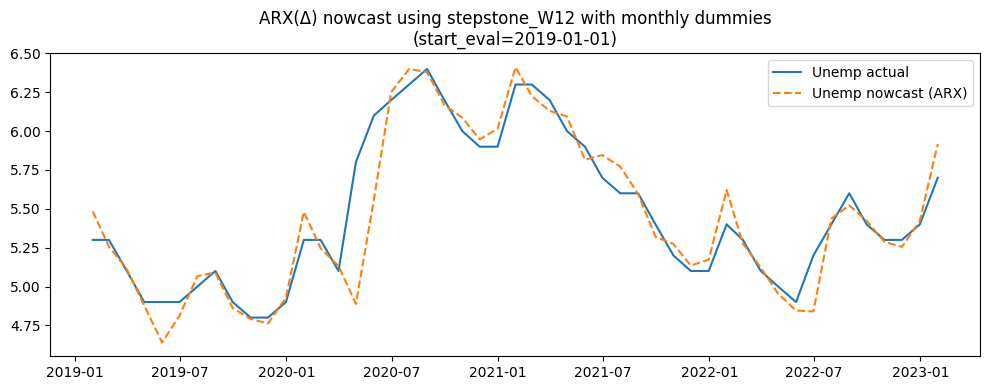

In [8]:
var_job_W12_forec, var_job_W12_act, rmse_job_W12, mae_job_W12, var_job_W12_model = \
    arx_diff_nowcast(panel,
                          gt_col="stepstone_W12",
                          start_eval="2019-01-01",
                          show_summary=True)

Lets look at some diagnostic


=== First 12 rows of evaluation ===
            Unemp_nowcast_ARX  Unemp_actual     error  abs_error  month
2019-01-31           5.483721           5.3  0.183721   0.183721      1
2019-02-28           5.257479           5.3 -0.042521   0.042521      2
2019-03-31           5.111306           5.1  0.011306   0.011306      3
2019-04-30           4.878401           4.9 -0.021599   0.021599      4
2019-05-31           4.639655           4.9 -0.260345   0.260345      5
2019-06-30           4.812168           4.9 -0.087832   0.087832      6
2019-07-31           5.067256           5.0  0.067256   0.067256      7
2019-08-31           5.089489           5.1 -0.010511   0.010511      8
2019-09-30           4.861946           4.9 -0.038054   0.038054      9
2019-10-31           4.790970           4.8 -0.009030   0.009030     10
2019-11-30           4.762125           4.8 -0.037875   0.037875     11
2019-12-31           4.926888           4.9  0.026888   0.026888     12

=== Worst 10 errors ===
  

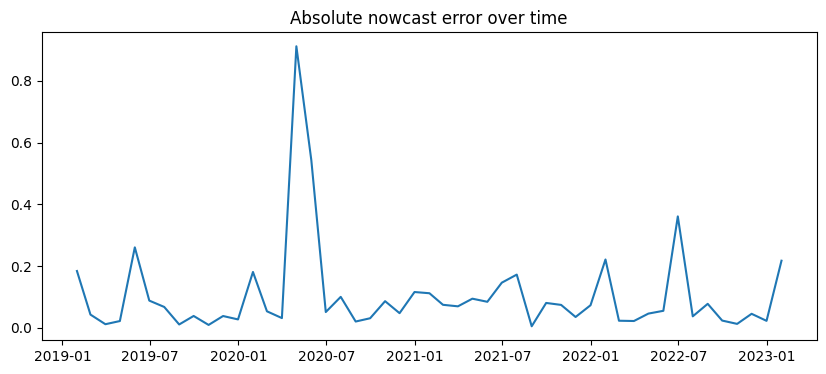


=== RMSE by month ===
month
1     0.186999
2     0.051610
3     0.039914
4     0.459073
5     0.305184
6     0.201027
7     0.106640
8     0.040369
9     0.048379
10    0.057204
11    0.041508
12    0.070514
Name: error, dtype: float64


In [9]:
# Combine actuals and forecasts
df_eval = pd.concat([var_job_W12_forec, var_job_W12_act], axis=1)
df_eval["error"] = df_eval["Unemp_nowcast_ARX"] - df_eval["Unemp_actual"]
df_eval["abs_error"] = df_eval["error"].abs()
df_eval["month"] = df_eval.index.month

print("\n=== First 12 rows of evaluation ===")
print(df_eval.head(12))

print("\n=== Worst 10 errors ===")
print(df_eval.sort_values("abs_error", ascending=False).head(10))

# Plot absolute error
plt.figure(figsize=(10,4))
plt.plot(df_eval["abs_error"])
plt.title("Absolute nowcast error over time")
plt.show()

# RMSE by month (to see seasonal failure patterns)
rmse_by_month = df_eval.groupby("month")["error"].apply(lambda x: np.sqrt(np.mean(x**2)))
print("\n=== RMSE by month ===")
print(rmse_by_month)


# AR(1) Nowcast

In [10]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

def ar_diff_nowcast(panel,
                    start_eval="2019-01-01",
                    p_ar=2,        # AR lags of ΔUnemp
                    min_train=60,
                    plot=True,
                    show_summary=True):
    """
    Rolling pseudo-real-time nowcast with AR model in first differences:
    ΔUnemp_t ~ AR(p) + monthly dummies.

    - Training sample for each forecast date t: all data with Date < t
    - Forecast horizon: 1 month ahead
    """

    df = panel[["Unemp"]].copy()
    df["Unemp"] = pd.to_numeric(df["Unemp"], errors="coerce")

    # first differences
    df["dUnemp"] = df["Unemp"].diff()

    # AR lags
    for i in range(1, p_ar + 1):
        df[f"dUnemp_lag{i}"] = df["dUnemp"].shift(i)

    # monthly dummies
    month_dummies = pd.get_dummies(df.index.month, prefix="m", drop_first=True)
    month_dummies.index = df.index

    reg_cols = [f"dUnemp_lag{i}" for i in range(1, p_ar + 1)]

    forecasts, actuals, dates = [], [], []
    last_model = None

    eval_dates = df.loc[start_eval:].index

    for t in eval_dates:
        df_est = df.loc[df.index < t].copy().iloc[1:]  # drop first diff NaN

        y_est = df_est["dUnemp"]
        X_est = df_est[reg_cols]

        dummies_est = month_dummies.loc[df_est.index]
        X_est = pd.concat([X_est, dummies_est], axis=1)

        reg_data = pd.concat([y_est, X_est], axis=1).dropna()

        if len(reg_data) < max(min_train, p_ar + 2):
            continue

        y_reg = reg_data["dUnemp"].astype(float)
        X_reg = reg_data.drop(columns=["dUnemp"]).astype(float)

        X_reg = sm.add_constant(X_reg)

        model = sm.OLS(y_reg, X_reg).fit()
        last_model = model

        # Build forecast row
        x_t = df.loc[[t], reg_cols]
        dummies_t = month_dummies.loc[[t]]

        x_t = pd.concat([x_t, dummies_t], axis=1).astype(float)
        x_t = sm.add_constant(x_t, has_constant="add")

        # predict ΔUnemp_t
        dU_pred = float(model.predict(x_t))

        # level forecast
        U_last = df.loc[df.index < t, "Unemp"].iloc[-1]
        U_pred = U_last + dU_pred

        forecasts.append(U_pred)
        actuals.append(df.loc[t, "Unemp"])
        dates.append(t)

    forecasts = pd.Series(forecasts, index=dates, name="Unemp_nowcast_AR")
    actuals = pd.Series(actuals, index=dates, name="Unemp_actual")

    errors = forecasts - actuals
    rmse = np.sqrt(np.mean(errors**2))
    mae = np.mean(np.abs(errors))

    print(f"\nAR(Δ) nowcast results: RMSE={rmse:.4f}, MAE={mae:.4f}")

    if show_summary and last_model is not None:
        print("\n=== Last AR(Δ) model summary ===")
        print(last_model.summary())

    if plot:
        plt.figure(figsize=(10, 4))
        plt.plot(actuals, label="Actual")
        plt.plot(forecasts, label="Forecast (AR)", linestyle="--")
        plt.title(f"AR(Δ) Nowcast (start_eval={start_eval})")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return forecasts, actuals, rmse, mae, last_model



AR(Δ) nowcast results: RMSE=0.1817, MAE=0.1032

=== Last AR(Δ) model summary ===
                            OLS Regression Results                            
Dep. Variable:                 dUnemp   R-squared:                       0.765
Model:                            OLS   Adj. R-squared:                  0.742
Method:                 Least Squares   F-statistic:                     33.55
Date:                Sun, 30 Nov 2025   Prob (F-statistic):           2.97e-33
Time:                        21:05:29   Log-Likelihood:                 111.38
No. Observations:                 137   AIC:                            -196.8
Df Residuals:                     124   BIC:                            -158.8
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------

/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_75809/1309523420.py:71: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  dU_pred = float(model.predict(x_t))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_75809/1309523420.py:71: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  dU_pred = float(model.predict(x_t))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_75809/1309523420.py:71: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  dU_pred = float(model.predict(x_t))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_75809/1309523420.py:71: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser

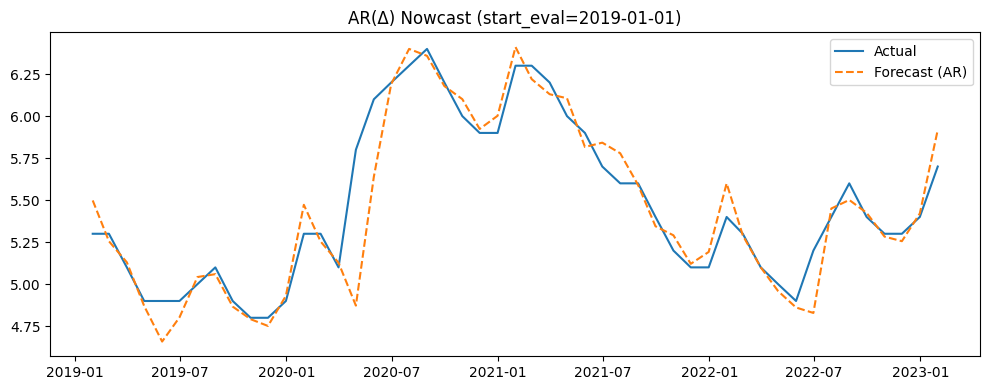

(2019-01-31    5.498222
 2019-02-28    5.255729
 2019-03-31    5.130163
 2019-04-30    4.869900
 2019-05-31    4.658608
 2019-06-30    4.802454
 2019-07-31    5.042468
 2019-08-31    5.059722
 2019-09-30    4.866584
 2019-10-31    4.791687
 2019-11-30    4.751404
 2019-12-31    4.930682
 2020-01-31    5.472242
 2020-02-29    5.254064
 2020-03-31    5.127583
 2020-04-30    4.872452
 2020-05-31    5.638385
 2020-06-30    6.190311
 2020-07-31    6.399884
 2020-08-31    6.358615
 2020-09-30    6.178726
 2020-10-31    6.100962
 2020-11-30    5.923543
 2020-12-31    6.002144
 2021-01-31    6.410961
 2021-02-28    6.219751
 2021-03-31    6.130347
 2021-04-30    6.106286
 2021-05-31    5.816316
 2021-06-30    5.842101
 2021-07-31    5.779056
 2021-08-31    5.589495
 2021-09-30    5.344477
 2021-10-31    5.290872
 2021-11-30    5.121133
 2021-12-31    5.191910
 2022-01-31    5.599915
 2022-02-28    5.289567
 2022-03-31    5.099965
 2022-04-30    4.958737
 2022-05-31    4.861243
 2022-06-30    4

In [11]:
ar_diff_nowcast(panel, p_ar=1)

## ARMA model

In [17]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

def armax_diff_nowcast(panel,
                       gt_col,
                       start_eval="2019-01-01",
                       p_max=2,      # max AR order to try
                       q_max=2,      # max MA order to try
                       K_gt=0,       # number of lags of ΔGT (0 = only contemporaneous)
                       min_train=60, # minimal obs in estimation window
                       ic="aic",     # "aic" or "bic"
                       plot=True,
                       show_summary=True):
    """
    Rolling pseudo-real-time nowcast with ARMAX in first differences:

    ΔUnemp_t ~ ARMA(p,q) + ΔGT_t (and lags up to K_gt) + monthly dummies.

    - Training sample for each forecast date t: all data with Date < t
    - Forecast horizon: 1 month ahead (nowcast current month t)
    - (p,q) chosen in small grid by AIC/BIC each time.

    Parameters
    ----------
    panel : DataFrame
        Must contain columns [gt_col, "Unemp"] and a DateTimeIndex.
    gt_col : str
        Column name of the Google Trends series to use.
    start_eval : str or Timestamp
        First date (inclusive) for which to start nowcasting.
    p_max, q_max : int
        Max AR and MA orders to consider in the (p,q) grid.
    K_gt : int
        Number of lags of ΔGT to include (0 = only ΔGT_t; 1 = ΔGT_t, ΔGT_{t-1}, ...).
    min_train : int
        Minimum number of usable observations required to estimate ARMAX.
    ic : {"aic","bic"}
        Information criterion used to select (p,q).
    """

    # 1) Keep only GT series and unemployment, convert to numeric
    df = panel[[gt_col, "Unemp"]].copy()
    df[gt_col] = pd.to_numeric(df[gt_col], errors="coerce")
    df["Unemp"] = pd.to_numeric(df["Unemp"], errors="coerce")

    # 2) First differences
    df["dUnemp"] = df["Unemp"].diff()
    df["dGT"] = df[gt_col].diff()

    # 3) Build ΔGT lags (including contemporaneous as lag 0)
    df["dGT_0"] = df["dGT"]  # contemporaneous ΔGT_t
    for k in range(1, K_gt + 1):
        df[f"dGT_lag{k}"] = df["dGT"].shift(k)

    # 4) Monthly dummies (Feb–Dec; Jan baseline)
    month_dummies = pd.get_dummies(df.index.month, prefix="m", drop_first=True)
    month_dummies.index = df.index

    # list of GT regressor columns
    gt_cols = ["dGT_0"] + [f"dGT_lag{k}" for k in range(1, K_gt + 1)]

    forecasts = []
    actuals = []
    dates = []
    last_model = None
    last_order = None
    order_history = {}  # store (p,q) per forecast date

    # Evaluation dates
    eval_dates = df.loc[start_eval:].index

    for t in eval_dates:
        # 1) Estimation sample: everything BEFORE t
        df_est = df.loc[df.index < t].copy()

        # drop first row (diff NaN) and potential early NaNs from lags
        df_est = df_est.iloc[1:]

        # y = ΔUnemp
        y_est = df_est["dUnemp"]

        # X = ΔGT terms + month dummies
        X_gt = df_est[gt_cols]
        dummies_est = month_dummies.loc[df_est.index]
        X_est = pd.concat([X_gt, dummies_est], axis=1)

        # Combine and drop rows with any NaN (from early lags)
        reg_data = pd.concat([y_est, X_est], axis=1).dropna()

        if len(reg_data) < min_train:
            # Not enough data yet, skip this t
            continue

        y_reg = reg_data["dUnemp"].astype(float)
        X_reg = reg_data.drop(columns=["dUnemp"]).astype(float)

        # 2) Select (p,q) by IC on a small grid
        best_ic = np.inf
        best_order = None
        best_res = None

        for p in range(0, p_max + 1):
            for q in range(0, q_max + 1):
                if p == 0 and q == 0:
                    # ARMA(0,0) is just white noise + exog; you can allow it if you want
                    continue
                try:
                    # d=0 because we already difference y_reg
                    model = sm.tsa.ARIMA(
                        y_reg,
                        order=(p, 0, q),
                        exog=X_reg
                    )
                    res = model.fit(method="statespace", disp=0)

                    value_ic = res.aic if ic.lower() == "aic" else res.bic
                    if value_ic < best_ic:
                        best_ic = value_ic
                        best_order = (p, q)
                        best_res = res
                except Exception:
                    # occasionally ARIMA fails to converge; just skip that order
                    continue

        if best_res is None:
            print(f"WARNING: No ARMAX model converged for forecast date {t}. Skipping.")
            continue

        armax_res = best_res
        last_model = armax_res
        last_order = best_order
        order_history[t] = best_order

        # 3) Build exogenous regressor row for forecast month t
        X_gt_t = df.loc[[t], gt_cols]
        dummies_t = month_dummies.loc[[t]]
        X_t = pd.concat([X_gt_t, dummies_t], axis=1).astype(float)

        # 4) One-step-ahead forecast of ΔUnemp_t
        dU_pred = float(armax_res.forecast(steps=1, exog=X_t))

        # 5) Back to level forecast: U_t = U_{t-1} + ΔU_t
        U_last = df.loc[df.index < t, "Unemp"].iloc[-1]
        U_pred = U_last + dU_pred

        forecasts.append(U_pred)
        actuals.append(df.loc[t, "Unemp"])
        dates.append(t)

    # Build series of forecasts and actuals
    forecasts = pd.Series(forecasts, index=dates, name="Unemp_nowcast_ARMAX")
    actuals = pd.Series(actuals, index=dates, name="Unemp_actual")

    errors = forecasts - actuals
    rmse = np.sqrt(np.mean(errors**2))
    mae = np.mean(np.abs(errors))

    print(f"\nARMAX(Δ) nowcast for {gt_col}: RMSE={rmse:.4f}, MAE={mae:.4f}")
    if last_order is not None:
        print(f"Last selected ARMA order (p,q) = {last_order}")

    if show_summary and last_model is not None:
        print("\n=== Last ARMAX(Δ) estimation summary ===")
        print(last_model.summary())

    if plot:
        plt.figure(figsize=(10, 4))
        plt.plot(actuals, label="Unemp actual")
        plt.plot(forecasts, label="Unemp nowcast (ARMAX)", linestyle="--")
        plt.title(
            f"ARMAX(Δ) nowcast using {gt_col} with monthly dummies\n"
            f"(start_eval={start_eval}, p_max={p_max}, q_max={q_max}, K_gt={K_gt})"
        )
        plt.legend()
        plt.tight_layout()
        plt.show()

    return forecasts, actuals, rmse, mae, last_model, order_history



ARMAX(Δ) nowcast for stepstone_W12: RMSE=nan, MAE=nan


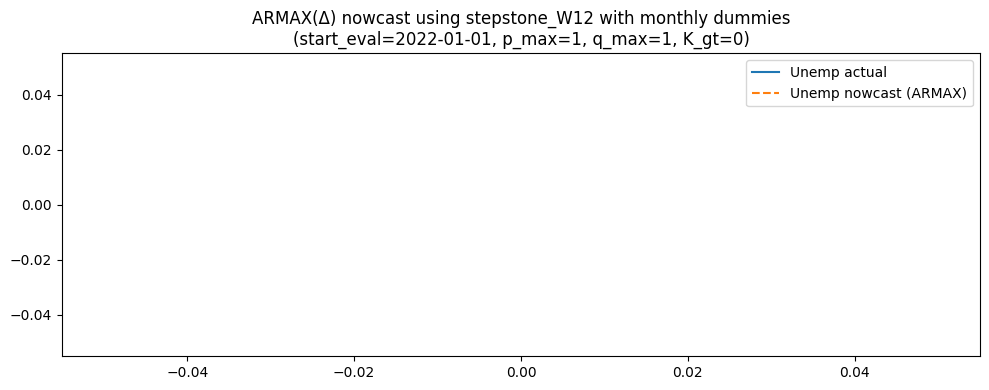

In [28]:
armax_forec, armax_act, rmse_armax, mae_armax, armax_model, armax_orders = \
    armax_diff_nowcast(
        panel,
        gt_col="stepstone_W12",
        start_eval="2022-01-01",
        p_max=1,
        q_max=1,
        K_gt=0,        # only contemporaneous ΔGT_t
        ic="aic",
        show_summary=True
    )


It does not necessarily mean GT is “wrong” or “has no signal” — but:

It means ΔGT_t has no statistical power in explaining ΔUnemp_t

in the likelihood-based ARMAX estimation framework.

In other words:

GT does not move with unemployment month-to-month in changes

The correlation is extremely low

GT does not help estimate an ARMA structure

That’s why ARMA+X fails but ARX (OLS) still works (and you already saw that with ARX).

OLS finds a coefficient even if β is nearly zero.

ARMA (maximum likelihood) needs a proper error structure — you don’t have one.

# Transformation we need for Midas

In [29]:
# Weekly GT → convert to period number within each month
df_week["month"] = df_week["Date"].dt.to_period("M")
df_week["week_in_month"] = df_week.groupby("month").cumcount()

# Typically there are 4–5 weeks per month
print(df_week["week_in_month"].max())

4


In [30]:
weekly_panel = (df_week
                .set_index("Date")
                [["indeed", "stepstone", "jobbörse", "arbeitsamt", "bewerbung"]]
               )


In [31]:
weekly_panel

,indeed,stepstone,jobbörse,arbeitsamt,bewerbung
Date,,,,,
2011-05-01,14.000000,49.000000,75.000000,86.000000,63.000000
2011-05-08,14.000000,50.000000,80.000000,84.000000,68.000000
2011-05-15,14.000000,52.000000,80.000000,87.000000,73.000000
2011-05-22,15.000000,52.000000,80.000000,83.000000,73.000000
2011-05-29,13.000000,42.000000,69.000000,73.000000,60.000000
...,...,...,...,...,...
2023-01-01,128.215336,60.670120,16.313392,26.270023,42.207649
2023-01-08,139.364496,58.450482,18.712420,30.773455,48.907276
2023-01-15,133.789916,65.109398,17.752809,30.773455,49.577239


In [32]:
import pandas as pd
import numpy as np

# --- 0. Ensure indices are proper DatetimeIndex ---
weekly = weekly_panel.copy()
monthly = unemp.copy()

weekly.index = pd.to_datetime(weekly.index)
monthly.index = pd.to_datetime(monthly.index)

# Optional: sort indices
weekly = weekly.sort_index()
monthly = monthly.sort_index()

# --- 1. First differences (stationarity) ---

# Monthly unemployment differences
monthly['dUnemp'] = monthly['Unemp'].diff()

# Weekly GT differences for one variable, say 'indeed'
weekly['indeed_diff'] = weekly['indeed'].diff()

# Drop first NA differences
monthly = monthly.dropna(subset=['dUnemp'])
weekly = weekly.dropna(subset=['indeed_diff'])

# --- 2. Choose number of weekly lags for MIDAS ---
K = 8  # e.g. 8 weekly lags

# --- 3. Build MIDAS-style dataset: one row per month, with K weekly lags ---

rows = []

for month_date, row in monthly.iterrows():
    # y_t: monthly change in unemployment at this month
    y = row['dUnemp']
    
    # all weekly observations up to this month_date
    weekly_up_to_month = weekly.loc[weekly.index <= month_date]
    
    # take the last K weekly differences (the "lags")
    if len(weekly_up_to_month) < K:
        # not enough history yet, skip this month
        continue
    
    last_K = weekly_up_to_month['indeed_diff'].iloc[-K:]
    
    # last_K is ordered from oldest to newest within that K-window
    # we want lag1 = most recent, so reverse
    lags = last_K.iloc[::-1].values  # now lags[0] = most recent week
    
    # store row: Date, dUnemp, lags...
    rows.append([month_date, y] + list(lags))

# Create DataFrame
colnames = ['Date', 'dUnemp'] + [f'lag{i+1}' for i in range(K)]
midas_df = pd.DataFrame(rows, columns=colnames).set_index('Date')

# --- 4. Add monthly seasonal dummies (since Unemp is NOT seasonally adjusted) ---

midas_df['month'] = midas_df.index.month
midas_df = pd.get_dummies(midas_df, columns=['month'], drop_first=True)


In [33]:
midas_df

,dUnemp,lag1,lag2,lag3,lag4,lag5,lag6,lag7,lag8,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
Date,,,,,,,,,,,,,,,,,,,,
2011-06-30,-0.1,0.000000,2.000000,-3.000000,3.000000,-2.000000,1.000000,0.000000,0.000000,False,False,False,False,True,False,False,False,False,False,False
2011-07-31,0.1,1.000000,-1.000000,-1.000000,1.000000,1.000000,0.000000,2.000000,-3.000000,False,False,False,False,False,True,False,False,False,False,False
2011-08-31,0.0,1.000000,-1.000000,1.000000,-1.000000,1.000000,-1.000000,-1.000000,1.000000,False,False,False,False,False,False,True,False,False,False,False
2011-09-30,-0.4,0.000000,0.000000,1.000000,0.000000,1.000000,-1.000000,1.000000,-1.000000,False,False,False,False,False,False,False,True,False,False,False
2011-10-31,-0.1,0.000000,-1.000000,1.000000,-1.000000,2.000000,0.000000,0.000000,1.000000,False,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-09-30,-0.2,-1.858193,0.000000,0.000000,-5.574580,7.432773,0.000000,3.716387,1.858193,False,False,False,False,False,False,False,True,False,False,False
2022-10-31,-0.1,1.858193,-7.432773,0.000000,11.149160,-5.574580,-1.858193,0.000000,0.000000,False,False,False,False,False,False,False,False,True,False,False
2022-11-30,0.0,3.716387,-22.298319,3.716387,3.716387,1.858193,-7.432773,0.000000,11.149160,False,False,False,False,False,False,False,False,False,True,False


# Unrestricted MIDAS function

In [34]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

def midas_unrestricted_nowcast(
    midas_df,
    unemp,
    start_eval="2019-01-01",
    p_ar=0,         # AR lags of dUnemp to include in MIDAS (0 = no AR term)
    min_train=60,   # minimal number of usable obs in estimation window
    plot=True,
    show_summary=True
):
    """
    Rolling pseudo-real-time nowcast with unrestricted MIDAS:

    ΔUnemp_t = α + Σ φ_i ΔUnemp_{t-i} + Σ β_w ΔGT_{t,w} + seasonal dummies + ε_t

    where ΔGT_{t,w} are the weekly differences stacked as lag1..lagK.

    Parameters
    ----------
    midas_df : DataFrame
        Monthly MIDAS design matrix with:
          - column 'dUnemp' (monthly change in unemployment),
          - columns 'lag1'...'lagK' (weekly GT differences),
          - monthly dummy columns (e.g. 'month_2', ..., 'month_12').
        Index must be a DateTimeIndex of month-end dates.

    unemp : DataFrame or Series
        Monthly unemployment levels ('Unemp') with DateTimeIndex.
        Used to reconstruct level forecasts: U_t = U_{t-1} + ΔU_t_hat.

    start_eval : str or Timestamp
        First month (by date) to start evaluating nowcasts.

    p_ar : int
        Number of AR lags of ΔUnemp to include (0 = none, 1 = ΔUnemp_{t-1}, etc).

    min_train : int
        Minimum number of usable obs required in the estimation window.

    plot : bool
        Plot actual vs nowcasted unemployment levels.

    show_summary : bool
        Print OLS summary of the last estimated MIDAS regression.

    Returns
    -------
    forecasts : Series
        Nowcasted unemployment levels (U_hat_t).

    actuals : Series
        Actual unemployment levels (U_t).

    rmse : float
        Root mean squared error of level nowcasts.

    mae : float
        Mean absolute error of level nowcasts.

    last_model : RegressionResults
        statsmodels OLS results from the last estimation window.
    """

    # Make defensive copies
    df = midas_df.copy()
    unemp = unemp.copy()

    # Ensure numeric
    df["dUnemp"] = pd.to_numeric(df["dUnemp"], errors="coerce")
    if isinstance(unemp, pd.DataFrame):
        U_series = pd.to_numeric(unemp["Unemp"], errors="coerce")
    else:  # Series
        U_series = pd.to_numeric(unemp, errors="coerce")

    # 1) Optionally add AR lags of ΔUnemp to the MIDAS dataframe
    if p_ar > 0:
        for i in range(1, p_ar + 1):
            df[f"dUnemp_lag{i}"] = df["dUnemp"].shift(i)

    # 2) Identify columns
    lag_cols = [c for c in df.columns if c.startswith("lag")]
    ar_cols  = [c for c in df.columns if c.startswith("dUnemp_lag")]
    dummy_cols = [c for c in df.columns if c.startswith("month_")]

    # Regressor set: weekly MIDAS lags + optional AR lags + dummies
    reg_cols = lag_cols + ar_cols + dummy_cols

    # Storage
    forecasts = []
    actuals = []
    dates = []
    last_model = None

    # Evaluation dates
    eval_dates = df.loc[start_eval:].index

    for t in eval_dates:
        # 1) Estimation sample: all data strictly BEFORE t
        df_est = df.loc[df.index < t].copy()

        # Drop rows with NaN from diffs or lags
        df_est = df_est.dropna(subset=["dUnemp"] + reg_cols)

        if len(df_est) < min_train:
            # Not enough usable data yet
            continue

        # Dependent variable
        y_est = df_est["dUnemp"].astype(float)

        # Regressors
        X_est = df_est[reg_cols].astype(float)

        # Add constant
        X_est = sm.add_constant(X_est)

        # 2) Fit OLS MIDAS regression
        midas_res = sm.OLS(y_est, X_est).fit()
        last_model = midas_res

        # 3) Build regressor vector for forecast date t
        row_t = df.loc[[t]].copy()
        # Need all regressor columns present and numeric
        X_t = row_t[reg_cols].astype(float)
        X_t = sm.add_constant(X_t, has_constant="add")

        # 4) Predict ΔUnemp_t
        dU_pred = float(midas_res.predict(X_t))

        # 5) Convert to level: U_hat_t = U_{t-1} + ΔU_pred
        U_last = U_series.loc[U_series.index < t].iloc[-1]
        U_pred = U_last + dU_pred

        forecasts.append(U_pred)
        actuals.append(U_series.loc[t])
        dates.append(t)

    # Construct result Series
    forecasts = pd.Series(forecasts, index=dates, name="Unemp_nowcast_MIDAS")
    actuals = pd.Series(actuals, index=dates, name="Unemp_actual")

    # Error metrics
    errors = forecasts - actuals
    rmse = np.sqrt(np.mean(errors**2))
    mae = np.mean(np.abs(errors))

    print(f"\nUnrestricted MIDAS(Δ) nowcast: RMSE={rmse:.4f}, MAE={mae:.4f}")
    if show_summary and last_model is not None:
        print("\n=== Last MIDAS(Δ) OLS summary ===")
        print(last_model.summary())

    if plot:
        plt.figure(figsize=(10, 4))
        plt.plot(actuals, label="Unemp actual")
        plt.plot(forecasts, label="Unemp nowcast (MIDAS)", linestyle="--")
        plt.title(
            f"Unrestricted MIDAS(Δ) nowcast with weekly GT\n"
            f"(start_eval={start_eval}, p_ar={p_ar})"
        )
        plt.legend()
        plt.tight_layout()
        plt.show()

    return forecasts, actuals, rmse, mae, last_model


/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_75809/3837346190.py:132: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  dU_pred = float(midas_res.predict(X_t))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_75809/3837346190.py:132: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  dU_pred = float(midas_res.predict(X_t))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_75809/3837346190.py:132: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  dU_pred = float(midas_res.predict(X_t))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_75809/3837346190.py:132: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the futur


Unrestricted MIDAS(Δ) nowcast: RMSE=0.1879, MAE=0.1276

=== Last MIDAS(Δ) OLS summary ===
                            OLS Regression Results                            
Dep. Variable:                 dUnemp   R-squared:                       0.826
Model:                            OLS   Adj. R-squared:                  0.796
Method:                 Least Squares   F-statistic:                     27.80
Date:                Sun, 30 Nov 2025   Prob (F-statistic):           3.01e-35
Time:                        22:33:03   Log-Likelihood:                 133.50
No. Observations:                 138   AIC:                            -225.0
Df Residuals:                     117   BIC:                            -163.5
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

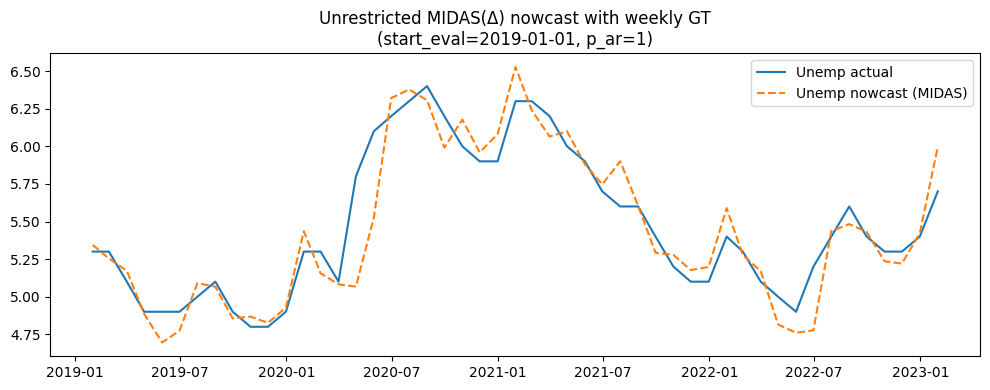

In [35]:
midas_forec, midas_act, rmse_midas, mae_midas, midas_model = \
    midas_unrestricted_nowcast(
        midas_df=midas_df,
        unemp=unemp,
        start_eval="2019-01-01",
        p_ar=1,          # include ΔUnemp_{t-1} as additional regressor
        min_train=60,
        show_summary=True
    )


In [36]:
def midas_error_diagnostics(forecasts, actuals, print_worst=10, plot=True):
    """
    Diagnostic tool for MIDAS (or any) nowcast errors.
    Computes errors, highlights worst predictions, and plots diagnostics.
    """

    df = pd.DataFrame({
        "Actual": actuals,
        "Forecast": forecasts
    }).dropna()

    df["Error"] = df["Forecast"] - df["Actual"]
    df["AbsError"] = df["Error"].abs()

    # Worst months
    worst = df.sort_values("AbsError", ascending=False).head(print_worst)

    print("\n=== WORST MONTHS (by absolute error) ===")
    print(worst[["Actual", "Forecast", "Error", "AbsError"]])

    # RMSE by year
    df["Year"] = df.index.year
    rmse_by_year = df.groupby("Year")["Error"].apply(lambda e: np.sqrt(np.mean(e**2)))

    print("\n=== RMSE BY YEAR ===")
    print(rmse_by_year)

    if plot:
        import matplotlib.pyplot as plt

        plt.figure(figsize=(12,4))
        plt.plot(df["AbsError"], label="Absolute Error")
        plt.title("MIDAS Absolute Forecast Error")
        plt.legend()
        plt.show()

        plt.figure(figsize=(6,6))
        plt.scatter(df["Actual"], df["Forecast"])
        plt.plot([df["Actual"].min(), df["Actual"].max()],
                 [df["Actual"].min(), df["Actual"].max()],
                 'r--')
        plt.title("Actual vs Nowcast (MIDAS)")
        plt.xlabel("Actual Unemployment")
        plt.ylabel("MIDAS Nowcast")
        plt.show()

    return df, worst, rmse_by_year



=== WORST MONTHS (by absolute error) ===
            Actual  Forecast     Error  AbsError
2020-04-30     5.8  5.067035 -0.732965  0.732965
2020-05-31     6.1  5.524918 -0.575082  0.575082
2022-06-30     5.2  4.776645 -0.423355  0.423355
2021-07-31     5.6  5.900665  0.300665  0.300665
2023-01-31     5.7  5.996043  0.296043  0.296043
2021-01-31     6.3  6.527782  0.227782  0.227782
2020-09-30     6.2  5.991080 -0.208920  0.208920
2019-05-31     4.9  4.695624 -0.204376  0.204376
2022-01-31     5.4  5.588606  0.188606  0.188606
2022-04-30     5.0  4.815284 -0.184716  0.184716
2020-12-31     5.9  6.080924  0.180924  0.180924
2020-10-31     6.0  6.176974  0.176974  0.176974

=== RMSE BY YEAR ===
Year
2019    0.083846
2020    0.295521
2021    0.132228
2022    0.158328
2023    0.296043
Name: Error, dtype: float64


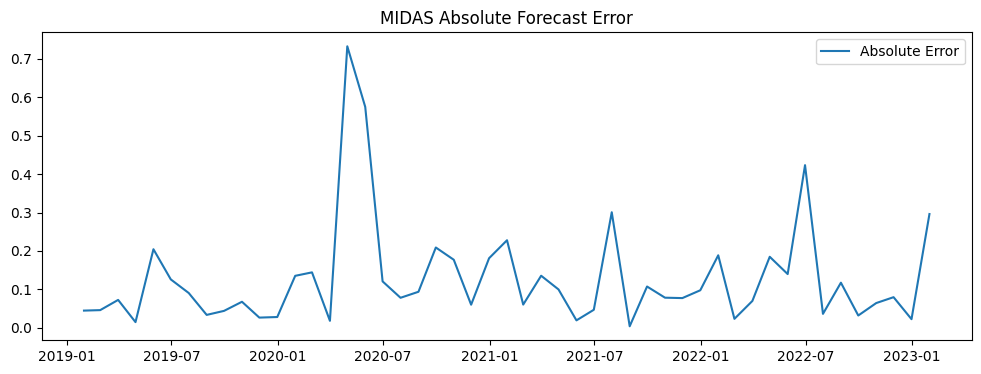

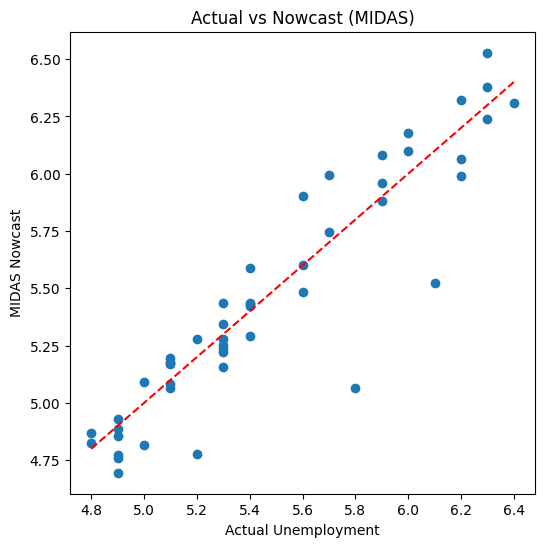

In [37]:
errors_df, worst_months, rmse_years = midas_error_diagnostics(
    forecasts=midas_forec,
    actuals=midas_act,
    print_worst=12
)


## Diebold Marino test

In [41]:
import numpy as np
from scipy.stats import t

def dm_test(e1, e2, h=1, crit="MSE"):
    """
    Diebold–Mariano test for equal predictive accuracy.

    Parameters
    ----------
    e1, e2 : array-like
        Forecast errors from model 1 and model 2 (aligned in time).
    h : int
        Forecast horizon. For your nowcasts: h = 1.
    crit : {"MSE", "MAE"}
        Loss function: squared error or absolute error.

    Returns
    -------
    DM_stat_corr : float
        Small-sample corrected DM statistic.
    p_value : float
        Two-sided p-value.
    """

    e1 = np.asarray(e1)
    e2 = np.asarray(e2)
    assert e1.shape == e2.shape, "Error series must be same length"

    if crit.upper() == "MSE":
        d = e1**2 - e2**2
    elif crit.upper() == "MAE":
        d = np.abs(e1) - np.abs(e2)
    else:
        raise ValueError("crit must be 'MSE' or 'MAE'")

    T = len(d)
    mean_d = np.mean(d)

    # Newey–West variance estimate with lag h-1
    gamma = [np.sum((d[i:] - mean_d) * (d[:T-i] - mean_d)) / T for i in range(h)]
    var_d = gamma[0] + 2 * sum((1 - k/h) * gamma[k] for k in range(1, h))

    DM_stat = mean_d / np.sqrt(var_d / T)

    # Harvey–Leybourne–Newbold small-sample correction
    df = T - 1
    DM_stat_corr = DM_stat * np.sqrt((T + 1 - 2*h + h*(h-1)/T) / T)
    p_value = 2 * (1 - t.cdf(np.abs(DM_stat_corr), df))

    return DM_stat_corr, p_value


In [43]:
# errors for overlapping period
errors_arx   = var_job_W12_forec - var_job_W12_act
errors_midas = midas_forec - midas_act

# align by common index
common_idx = errors_arx.index.intersection(errors_midas.index)
e1 = errors_arx.loc[common_idx].values
e2 = errors_midas.loc[common_idx].values

dm_stat, pval = dm_test(e1, e2, h=1, crit="MSE")
print("DM stat:", dm_stat, "p-value:", pval)


DM stat: -0.1844629207362978 p-value: 0.8544274578931161


# MIDAS

In [50]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def exp_almon_weights(theta, K):
    """
    Exponential Almon lag weights for k=1,...,K.
    theta: array-like [theta1, theta2]
    """
    theta1, theta2 = theta
    k = np.linspace(0, 1, K)
    a = np.exp(theta1 * k + theta2 * k**2)
    return a / a.sum()


def restricted_midas_nowcast(
    midas_df,
    unemp,
    start_eval="2019-01-01",
    p_ar=1,        # AR lags of dUnemp
    min_train=60,  # minimal obs in estimation window
    plot=True,
    show_theta=True
):
    """
    Rolling-window restricted MIDAS nowcast with Exponential Almon weights.

    Model:
      dUnemp_t = alpha + sum_i phi_i dUnemp_{t-i}
                 + beta * sum_k w_k(theta) * lag_k_t
                 + seasonal dummies + error_t

    where lag_k_t are weekly dGT lags and w_k(theta) are Almon weights.

    Parameters
    ----------
    midas_df : DataFrame
        Must contain:
          - 'dUnemp'
          - 'lag1'...'lagK'
          - monthly dummies 'month_2',..., 'month_12'
    unemp : DataFrame or Series
        Original unemployment levels ('Unemp') with DateTimeIndex.
    start_eval : str or Timestamp
        First month to start evaluating nowcasts.
    p_ar : int
        Number of AR lags of dUnemp.
    min_train : int
        Minimum number of usable observations for estimation.
    """

    df = midas_df.copy()
    if isinstance(unemp, pd.DataFrame):
        U_series = pd.to_numeric(unemp["Unemp"], errors="coerce")
    else:
        U_series = pd.to_numeric(unemp, errors="coerce")

    df["dUnemp"] = pd.to_numeric(df["dUnemp"], errors="coerce")

    # Identify columns
    lag_cols = [c for c in df.columns if c.startswith("lag")]
    K = len(lag_cols)
    dummy_cols = [c for c in df.columns if c.startswith("month_")]

    # Add AR lags of dUnemp if needed
    if p_ar > 0:
        for i in range(1, p_ar+1):
            df[f"dUnemp_lag{i}"] = df["dUnemp"].shift(i)
    ar_cols = [c for c in df.columns if c.startswith("dUnemp_lag")]

    forecasts = []
    actuals = []
    dates = []
    last_theta = None
    last_beta = None

    eval_dates = df.loc[start_eval:].index

    for t in eval_dates:
        # Estimation sample: all months before t
        df_est = df.loc[df.index < t].copy()

        # drop rows with missing dUnemp or lags
        df_est = df_est.dropna(subset=["dUnemp"] + lag_cols + ar_cols + dummy_cols)

        if len(df_est) < min_train:
            continue

        y = df_est["dUnemp"].values
        Z = df_est[lag_cols].values  # weekly lags matrix (T x K)
        D = df_est[dummy_cols].values if dummy_cols else np.empty((len(df_est), 0))

        if p_ar > 0:
            A = df_est[ar_cols].values  # AR lags of dUnemp
        else:
            A = np.empty((len(df_est), 0))

        T = len(df_est)

        # objective function for NLS over theta
        def obj(theta):
            w = exp_almon_weights(theta, K)
            x_midas = Z @ w  # T-vector

            X_parts = [np.ones(T)]  # constant
            if p_ar > 0:
                X_parts.append(A)
            X_parts.append(x_midas.reshape(-1, 1))
            if D.shape[1] > 0:
                X_parts.append(D)

            X = np.column_stack(X_parts)

            # OLS for linear parameters given theta
            beta_hat, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
            resid = y - X @ beta_hat
            return np.sum(resid**2)

        # initial guess for theta
        theta0 = np.array([-0.1, 0.01])
        res_optim = minimize(obj, theta0, method="L-BFGS-B",
                             bounds=[(-1.5, 1.5), (-0.1, 0.1)])

        theta_hat = res_optim.x
        w_hat = exp_almon_weights(theta_hat, K)

        # once theta_hat is known, re-estimate linear params
        x_midas_est = Z @ w_hat
        X_parts = [np.ones(T)]
        if p_ar > 0:
            X_parts.append(A)
        X_parts.append(x_midas_est.reshape(-1, 1))
        if D.shape[1] > 0:
            X_parts.append(D)
        X_est = np.column_stack(X_parts)
        beta_hat, _, _, _ = np.linalg.lstsq(X_est, y, rcond=None)

        last_theta = theta_hat
        last_beta = beta_hat

        # Build regressor row for forecast date t
        row_t = df.loc[[t]]
        z_t = row_t[lag_cols].values.reshape(1, -1)
        x_midas_t = (z_t @ w_hat).flatten()[0]

        X_parts_t = [np.array([1.0])]
        if p_ar > 0:
            A_t = row_t[ar_cols].values.flatten()
            X_parts_t.append(A_t)
        X_parts_t.append(np.array([x_midas_t]))
        if dummy_cols:
            D_t = row_t[dummy_cols].values.flatten()
            X_parts_t.append(D_t)

        X_t = np.concatenate(X_parts_t).reshape(1, -1)

        # predict dUnemp_t
        dU_pred = float(X_t @ beta_hat)

        # level nowcast: U_t = U_{t-1} + dU_pred
        U_last = U_series.loc[U_series.index < t].iloc[-1]
        U_pred = U_last + dU_pred

        forecasts.append(U_pred)
        actuals.append(U_series.loc[t])
        dates.append(t)

    forecasts = pd.Series(forecasts, index=dates, name="Unemp_nowcast_MIDAS_res")
    actuals = pd.Series(actuals, index=dates, name="Unemp_actual")

    errors = forecasts - actuals
    rmse = np.sqrt(np.mean(errors**2))
    mae = np.mean(np.abs(errors))

    print(f"\nRestricted MIDAS (Exp-Almon) nowcast: RMSE={rmse:.4f}, MAE={mae:.4f}")
    if show_theta and last_theta is not None:
        print("Last theta_hat (theta1, theta2):", last_theta)
        print("Last beta_hat (linear params, order: const, AR-lags, MIDAS, dummies...):")
        print(last_beta)

    if plot:
        plt.figure(figsize=(10,4))
        plt.plot(actuals, label="Unemp actual")
        plt.plot(forecasts, label="Unemp nowcast (res. MIDAS)", linestyle="--")
        plt.title(
            f"Restricted MIDAS (Exp-Almon) nowcast\n"
            f"(start_eval={start_eval}, p_ar={p_ar})"
        )
        plt.legend()
        plt.tight_layout()
        plt.show()

    return forecasts, actuals, rmse, mae, last_theta, last_beta



Restricted MIDAS (Exp-Almon) nowcast: RMSE=0.1936, MAE=0.1129
Last theta_hat (theta1, theta2): [1.5 0.1]
Last beta_hat (linear params, order: const, AR-lags, MIDAS, dummies...):
[ 0.47142812  0.41221779 -0.01320267 -0.65649312 -0.66179716 -0.55517761
 -0.5582627  -0.46012911 -0.32881019 -0.43452916 -0.70951552 -0.49208587
 -0.45135495 -0.38111744]


/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_75809/1298762975.py:160: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dU_pred = float(X_t @ beta_hat)
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_75809/1298762975.py:160: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dU_pred = float(X_t @ beta_hat)
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_75809/1298762975.py:160: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dU_pred = float

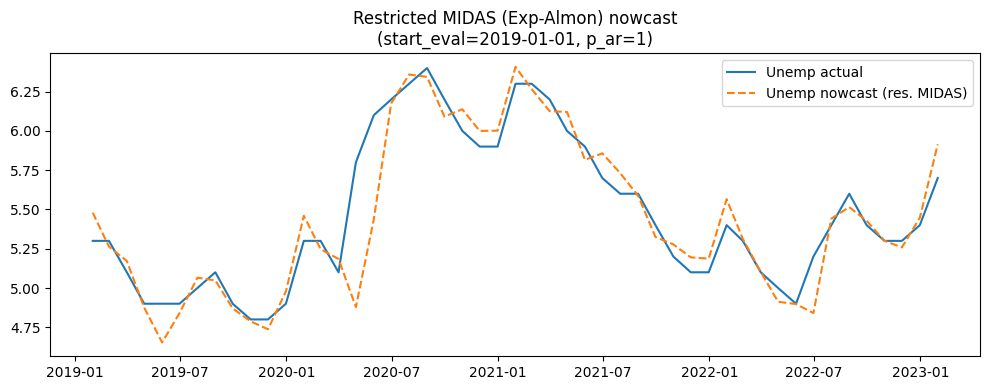

In [51]:
res_forec, res_act, rmse_res, mae_res, theta_hat, beta_hat = \
    restricted_midas_nowcast(
        midas_df=midas_df,
        unemp=unemp,
        start_eval="2019-01-01",
        p_ar=1,
        min_train=60,
        plot=True
    )


"After stabilizing the Exponential Almon lag function by rescaling and bounding parameters, the restricted MIDAS converges. However, the weekly GT signal remains weak and the lag-shape parameters are only weakly identified. Therefore, restricted MIDAS does not meaningfully outperform ARX or unrestricted MIDAS."